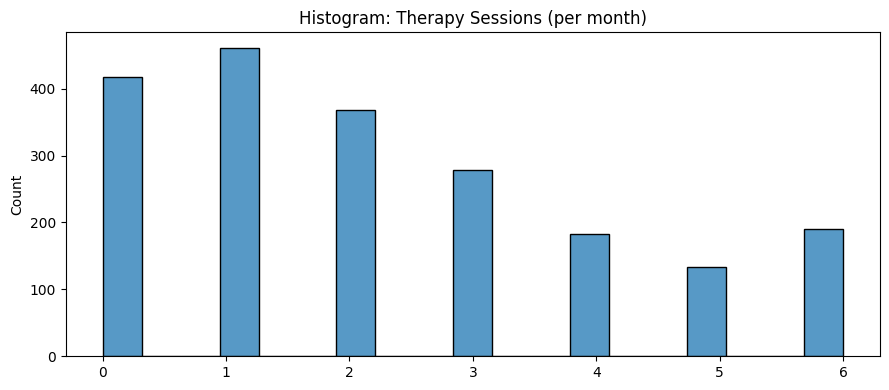

{'column': 'Therapy Sessions (per month)',
 'is_normal': False,
 'p_value': 3.1229377148805944e-35,
 'statistic': 0.894324162290143}

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr
import statsmodels.api as sm


df = pd.read_csv("social_anxiety_dataset_cleaned.csv")

def check_normal(series):
    
    values = series.dropna().values
    
    statistic, p_value = stats.shapiro(values)
    
    is_normal = p_value > 0.05
    
    fig, axes = plt.subplots(figsize=(9, 4))
    
    sns.histplot(values, ax=axes)
    axes.set_title(f'Histogram: {series.name}')
    
    plt.tight_layout()
    plt.show()
    
    return {'column': series.name, 'is_normal': is_normal, 'p_value': p_value, 'statistic': statistic}


#---------------------------------------------------------------------------------------------------------------


def spearman_test(column1, column2):
    
    temp = df[[column1, column2]].dropna()
    
    rho, p_value = spearmanr(temp[column1], temp[column2])
    
    if p_value < 0.05:
        significance = "Significant"
    else:
        significance = "Not Significant"
    
    print(f"Variable 1: {column1}")
    print(f"Variable 2: {column2}")
    print(f"Spearman rho: {rho:.4f}")
    print(f"p-value: {p_value:.6f}")
    print(f"Result: {significance}")
    
    return {'variable_1': column1, 'variable_2': column2, 'rho': rho, 'p_value': p_value, 'significance': significance}


def plot_relationship(column1, column2):
    
    temp = df[[column1, column2]].dropna()
    
    sns.scatterplot(data=temp, x=column1, y=column2)
    
    plt.title(f'{column1} vs {column2}')
    plt.tight_layout()
    plt.show()







check_normal(df['Therapy Sessions (per month)'])

In [8]:
spearman_test("Sleep Hours", "Physical Activity (hrs/week)")

Variable 1: Sleep Hours
Variable 2: Physical Activity (hrs/week)
Spearman rho: 0.1243
p-value: 0.000000
Result: Significant


{'variable_1': 'Sleep Hours',
 'variable_2': 'Physical Activity (hrs/week)',
 'rho': 0.12431701319066728,
 'p_value': 1.914781712694861e-08,
 'significance': 'Significant'}

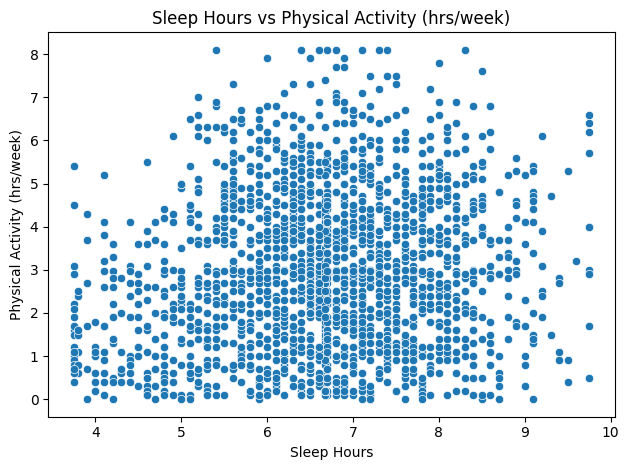

In [9]:
plot_relationship("Sleep Hours", "Physical Activity (hrs/week)")

In [6]:
#----------------------statistic analysis with 3 variables----------------------
#تحلیل آماری سه متغیره

In [4]:
def logistic_regression(predictors):

    columns = predictors + ["Target"]
    temp = df[columns].dropna()

    X = temp[predictors]
    y = temp["Target"]

    X = sm.add_constant(X)

    model = sm.Logit(y, X).fit()

    print(model.summary())


In [13]:
logistic_regression(["Sleep Hours", "Physical Activity (hrs/week)"])

Optimization terminated successfully.
         Current function value: 0.155853
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                 Target   No. Observations:                 2030
Model:                          Logit   Df Residuals:                     2027
Method:                           MLE   Df Model:                            2
Date:                Wed, 23 Sep 2026   Pseudo R-squ.:                  0.5314
Time:                        16:16:50   Log-Likelihood:                -316.38
converged:                       True   LL-Null:                       -675.17
Covariance Type:            nonrobust   LLR p-value:                1.519e-156
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           10.4518      0.699     14.949      0.000

In [7]:
#---------------------------one sample t-test-------------------------------
#آزمون فرض تک متغیره

In [20]:
def one_sample_t_test(column, hypothesized_mean):

    data = df[column].dropna()

    t_stat, p_value = stats.ttest_1samp(data, popmean=hypothesized_mean)

    print(f"Column: {column}")
    print(f"Hypothesized mean: {hypothesized_mean}")
    print(f"Sample mean: {data.mean():.4f}")
    print(f"t-statistic: {t_stat:.4f}")
    print(f"p-value: {p_value:.4f}")

    if p_value < 0.05:
        print("H0 rejected.")
    else:
        print("can not reject H0.")



In [21]:
one_sample_t_test("Caffeine Intake (mg/day)", 2)

Column: Caffeine Intake (mg/day)
Hypothesized mean: 2
Sample mean: 294.2389
t-statistic: 88.4169
p-value: 0.0000
H0 rejected.


In [1]:
#----------------------------two sample t-test---------------------------
#آزمون فرض با دو متغیر

In [23]:
def two_sample_t_test(column):

    group_0 = df[df["Target"] == 0][column].dropna()
    group_1 = df[df["Target"] == 1][column].dropna()

    t_stat, p_value = stats.ttest_ind(group_0, group_1, equal_var=False)

    print("t-statistic:", t_stat)
    print("p-value:", p_value)

    if p_value < 0.05:
        print("H0 rejected.")
    else:
        print("can not reject H0.")

In [24]:
two_sample_t_test("Breathing Rate (breaths/min)")

t-statistic: -11.427767866950003
p-value: 2.123561710321394e-25
H0 rejected.


In [25]:
two_sample_t_test("Sleep Hours")

t-statistic: 27.41936131329532
p-value: 8.346556446222e-80
H0 rejected.


In [26]:
def t_test_greater(value_column):

    data_1 = df[df["Target"] == 0][value_column].dropna()
    data_0 = df[df["Target"] == 1][value_column].dropna()

    t_stat, p_value = stats.ttest_ind(data_1, data_0, equal_var=False, alternative="greater")

    print(f"t-statistic: {t_stat:.4f}")
    print(f"p-value: {p_value:.4f}")

    if p_value < 0.05:
        print("H0 rejected.")
    else:
        print("can not reject H0.")


In [27]:
t_test_greater("Caffeine Intake (mg/day)")

t-statistic: -19.4799
p-value: 1.0000
can not reject H0.


In [28]:
def t_test_less(value_column):

    data_1 = df[df["Target"] == 0][value_column].dropna()
    data_0 = df[df["Target"] == 1][value_column].dropna()

    t_stat, p_value = stats.ttest_ind(data_1, data_0, equal_var=False, alternative="less")

    print(f"t-statistic: {t_stat:.4f}")
    print(f"p-value: {p_value:.4f}")

    if p_value < 0.05:
        print("H0 rejected.")
    else:
        print("can not reject H0.")


In [29]:
t_test_less("Caffeine Intake (mg/day)")

t-statistic: -19.4799
p-value: 0.0000
H0 rejected.


In [19]:
def two_sample_mai(column):
    mean = df[column].mean()

    # t0 = df[df[column] < mean]["Target"].dropna()
    # t1 = df[df[column] >= mean]["Target"].dropna()
    t0 = df[df[column] > mean]["Target"].dropna()
    t1 = df[df[column] <= mean]["Target"].dropna()
    t_stat, p_value = stats.ttest_ind(t0, t1, equal_var=False, alternative="greater")
    
    print("Mean:", mean)

    print("mean 0:", t0.mean())
    print("mean 1:", t1.mean())

    print("t-statistic:", t_stat)
    print("p-value:", p_value)

    if p_value < 0.05:
        print("H0 rejected.")
    else:
        print("can not reject H0.")


In [20]:
def two_sample_main(column):
    mean = df[column].mean()

    young = df[df[column] <= mean]["Target"].dropna()
    old = df[df[column] > mean]["Target"].dropna()

    t_stat, p_value = stats.ttest_ind(
        young,
        old,
        equal_var=False,
        alternative="greater"
    )

    print("Mean:", mean)
    print("Young mean:", young.mean())
    print("Older mean:", old.mean())
    print("t-statistic:", t_stat)
    print("p-value:", p_value)

    if p_value < 0.05:
        print("H0 rejected.")
    else:
        print("Cannot reject H0.")

In [21]:
two_sample_main("Age")

Mean: 39.921747967479675
Young mean: 0.1344364012409514
Older mean: 0.07525870178739416
t-statistic: 4.33922780313012
p-value: 7.542697047884283e-06
H0 rejected.
